# Statistical Hypothesis Testing

## Objective

This notebook performs statistical hypothesis testing to determine whether the behavioural differences observed between retained and non-retained players during the first 24 hours are statistically significant.

Rather than testing every engineered feature individually, one representative feature was selected from each behavioural dimension to avoid redundancy while providing comprehensive coverage of player behaviour.

The selected behavioural dimensions include:

- Engagement
- Exploration
- Progression
- Persistence
- Gameplay Intensity
- Play Style

The findings from this notebook provide statistical evidence supporting Research Question 2 and establish whether the observed behavioural differences identified during the exploratory data analysis are statistically significant.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats

from scipy.stats import (
    shapiro,
    mannwhitneyu,
    ttest_ind,
    levene
)

In [2]:
# Load analytical dataset

df = pd.read_csv("../data/player_features_final.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (11080, 35)


,pid,age,gender,country,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,...,max_session_length,distinct_jobs_played,interruption_count,avg_interruption_session,longest_interrupted_session,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
0,p10032,35.0,Female,USA,1,0,1,0.0,2,2,...,5,2,2,17.5,30,1.0,0.0,0.0,0.0,1
1,p10033,18.0,Male,UK,1,0,1,0.0,2,2,...,8,2,2,8.5,9,1.0,0.0,0.0,0.0,0
2,p4777,44.0,Male,USA,0,0,0,0.0,0,0,...,0,0,0,0.0,0,0.0,0.0,0.0,0.0,1
3,p6114,40.0,Male,Taiwan,1,0,1,0.0,0,0,...,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0
4,p7611,47.0,Male,USA,0,0,0,0.0,0,0,...,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11080 entries, 0 to 11079
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pid                           11080 non-null  object 
 1   age                           10964 non-null  float64
 2   gender                        11018 non-null  object 
 3   country                       10670 non-null  object 
 4   login_count_24h               11080 non-null  int64  
 5   repeat_login_count_24h        11080 non-null  int64  
 6   active_days_24h               11080 non-null  int64  
 7   avg_login_gap_minutes         11080 non-null  float64
 8   jobs_started_24h              11080 non-null  int64  
 9   unique_jobs_started_24h       11080 non-null  int64  
 10  career_jobs_started_24h       11080 non-null  int64  
 11  special_jobs_started_24h      11080 non-null  int64  
 12  freeplay_jobs_started_24h     11080 non-null  int64  
 13  c

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10964.0,28.251186,8.813566,18.0,21.0,27.000000,33.000,118.000000
login_count_24h,11080.0,1.013177,1.142365,0.0,0.0,1.000000,1.000,23.000000
repeat_login_count_24h,11080.0,0.384116,0.886928,0.0,0.0,0.000000,0.000,22.000000
active_days_24h,11080.0,0.728339,0.629645,0.0,0.0,1.000000,1.000,2.000000
avg_login_gap_minutes,11080.0,109.310749,263.815408,0.0,0.0,0.000000,0.000,1424.950000
jobs_started_24h,11080.0,2.409296,4.545791,0.0,0.0,1.000000,3.000,100.000000
unique_jobs_started_24h,11080.0,2.318682,3.970758,0.0,0.0,1.000000,3.000,60.000000
career_jobs_started_24h,11080.0,2.207220,3.793028,0.0,0.0,1.000000,3.000,76.000000
special_jobs_started_24h,11080.0,0.100361,0.477341,0.0,0.0,0.000000,0.000,10.000000
freeplay_jobs_started_24h,11080.0,0.074549,1.139610,0.0,0.0,0.000000,0.000,60.000000


In [5]:
df["retained"].value_counts()

retained
1    5570
0    5510
Name: count, dtype: int64

## Representative Feature Selection

The study engineered multiple behavioural variables describing different aspects of player behaviour.

To avoid redundant statistical testing among highly correlated variables, one representative feature was selected from each behavioural dimension.

These representative features provide comprehensive coverage of player behaviour while maintaining methodological simplicity.

In [6]:
selected_features = [
    "login_count_24h",
    "jobs_started_24h",
    "jobs_completed_24h",
    "jobs_exited_24h",
    "avg_session_length",
    "career_play_ratio"
]

selected_features

['login_count_24h',
 'jobs_started_24h',
 'jobs_completed_24h',
 'jobs_exited_24h',
 'avg_session_length',
 'career_play_ratio']

## Distribution Analysis

Before selecting an appropriate statistical test, the distribution of each representative behavioural feature was examined.

Visual inspection was performed using histograms and boxplots to identify skewness, outliers, and overall distribution characteristics. This provides additional context when interpreting the formal normality test results.

In [7]:
feature_labels = {
    "login_count_24h": "Login Count",
    "jobs_started_24h": "Jobs Started",
    "jobs_completed_24h": "Jobs Completed",
    "jobs_exited_24h": "Jobs Exited",
    "avg_session_length": "Average Session Length",
    "career_play_ratio": "Career Play Ratio"
}

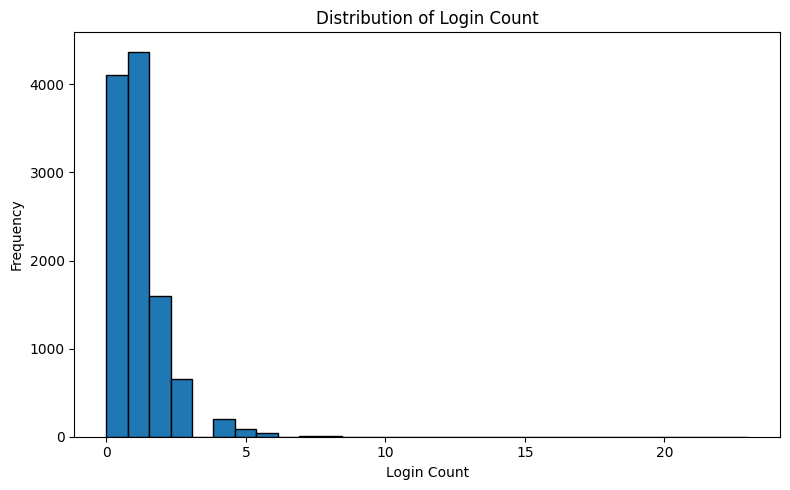

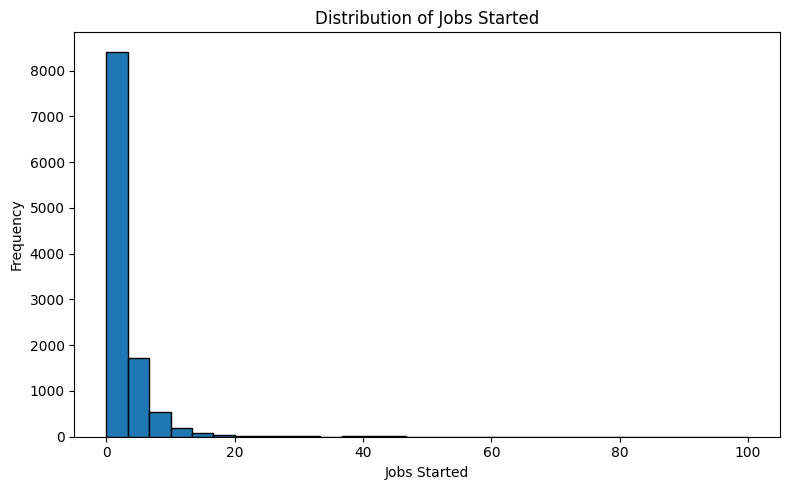

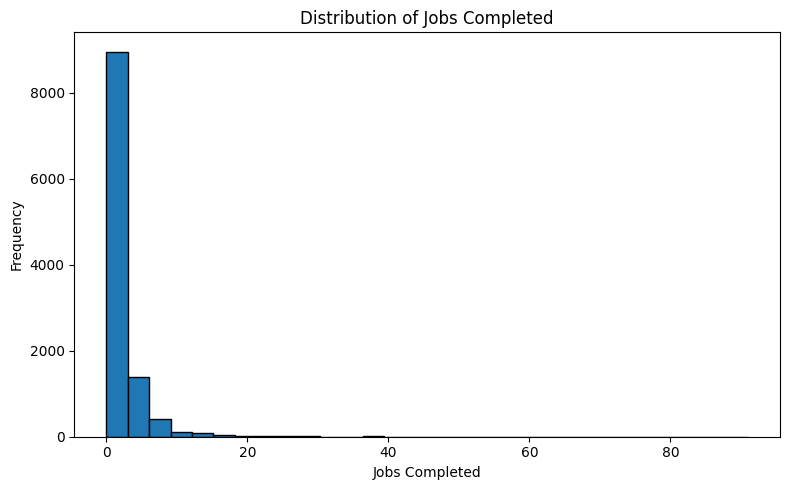

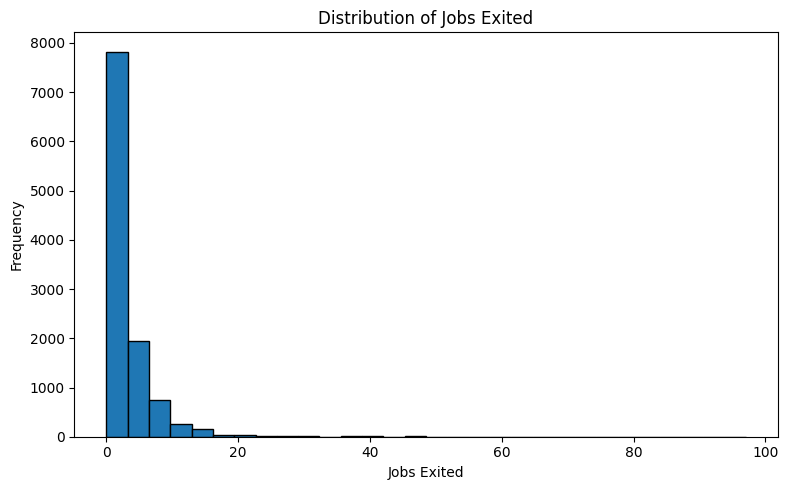

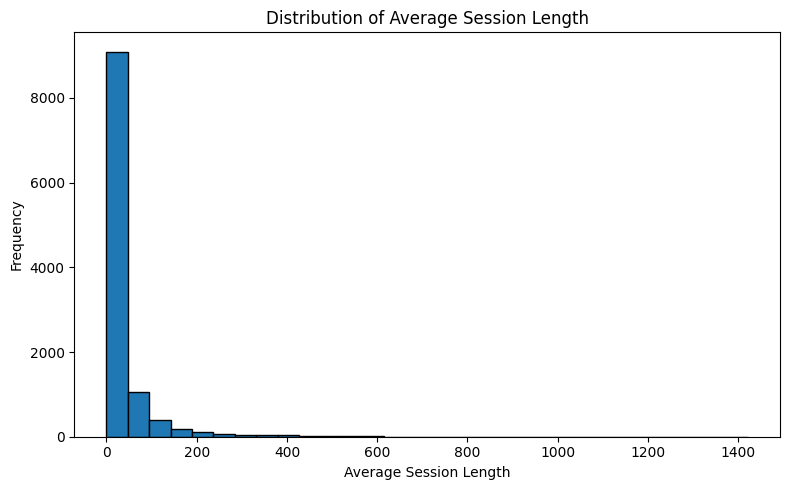

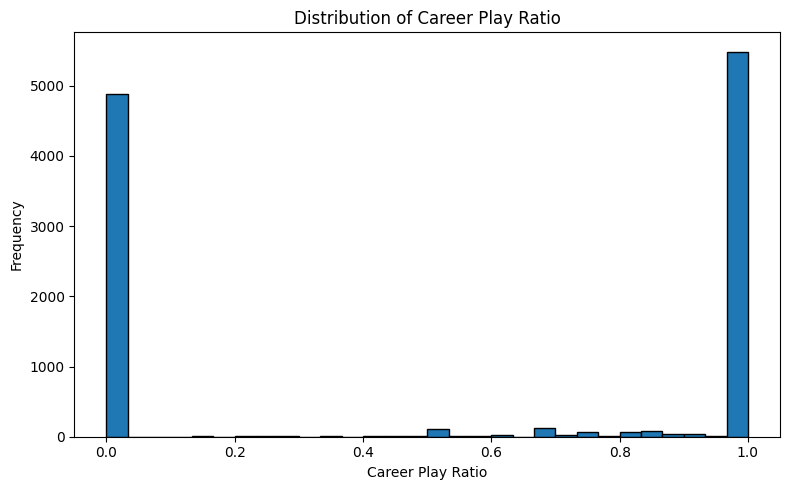

In [11]:
for feature, label in feature_labels.items():

    plt.figure(figsize=(8,5))

    plt.hist(
        df[feature],
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

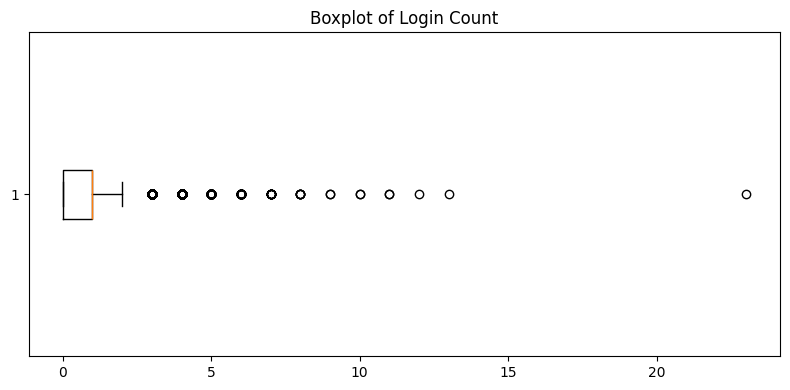

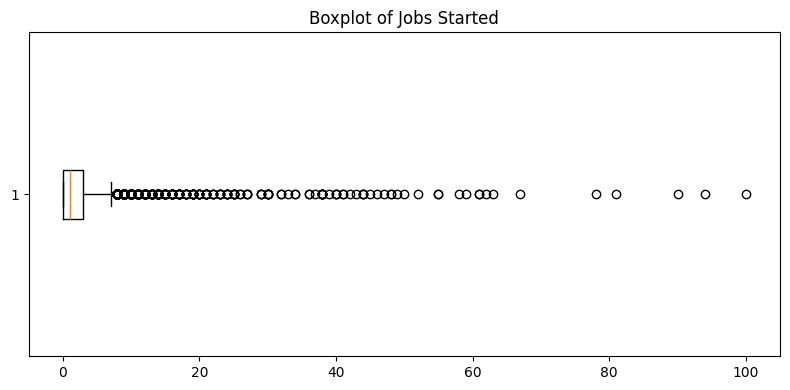

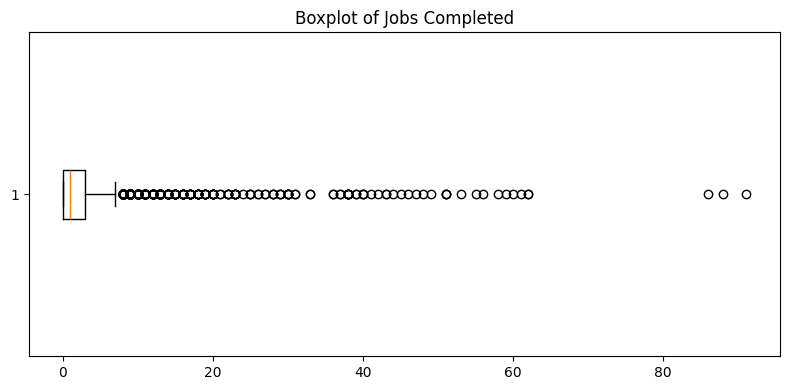

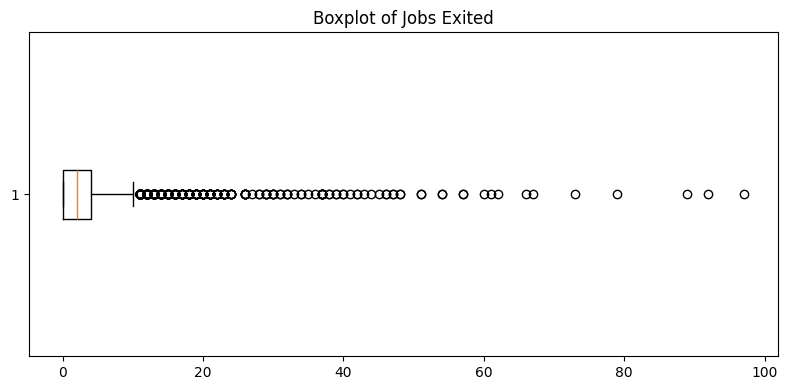

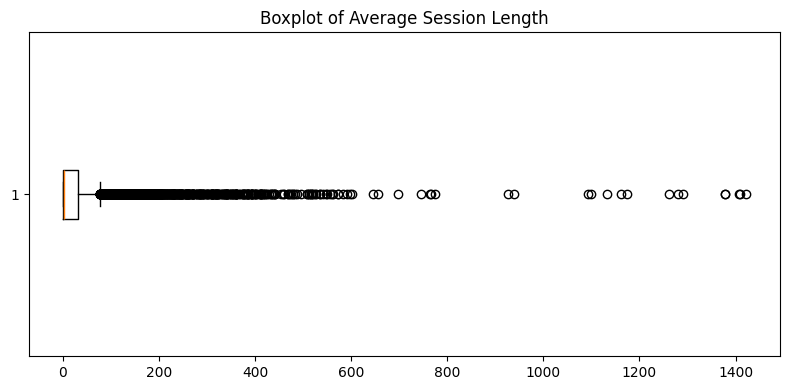

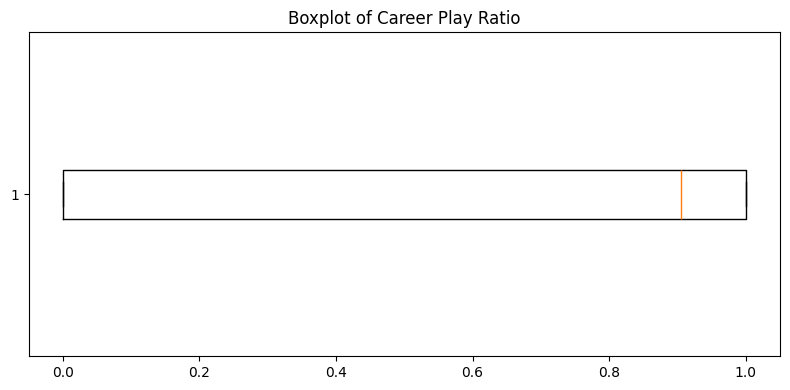

In [10]:
for feature, label in feature_labels.items():

    plt.figure(figsize=(8,4))

    plt.boxplot(df[feature], vert=False)

    plt.title(f"Boxplot of {label}")

    plt.tight_layout()
    plt.show()

## Shapiro–Wilk Normality Test

Following the visual inspection of the representative behavioural features, the Shapiro–Wilk test was performed to formally evaluate the assumption of normality.

The test was conducted separately for retained and non-retained players because the subsequent hypothesis tests compare these two independent groups.

### Hypotheses

**Null Hypothesis (H₀):**
The feature follows a normal distribution.

**Alternative Hypothesis (H₁):**
The feature does not follow a normal distribution.

A significance level of α = 0.05 was used throughout the study.

In [12]:
normality_results = []

for feature, label in feature_labels.items():

    retained = df[df["retained"] == 1][feature]
    non_retained = df[df["retained"] == 0][feature]

    stat_retained, p_retained = shapiro(retained)
    stat_non_retained, p_non_retained = shapiro(non_retained)

    normality_results.append({
        "Feature": label,
        "Retained p-value": p_retained,
        "Non-Retained p-value": p_non_retained,
        "Retained Normal?": "Yes" if p_retained >= 0.05 else "No",
        "Non-Retained Normal?": "Yes" if p_non_retained >= 0.05 else "No"
    })

normality_results = pd.DataFrame(normality_results)

normality_results

,Feature,Retained p-value,Non-Retained p-value,Retained Normal?,Non-Retained Normal?
0,Login Count,7.146707e-63,1.184838e-71,No,No
1,Jobs Started,3.004615e-79,5.552028e-89,No,No
2,Jobs Completed,4.380504e-80,4.733928e-90,No,No
3,Jobs Exited,3.160433e-75,1.363425e-87,No,No
4,Average Session Length,3.885446e-83,1.475187e-91,No,No
5,Career Play Ratio,3.111259e-76,2.355112e-75,No,No


In [13]:
mannwhitney_results = []

for feature, label in feature_labels.items():

    retained = df[df["retained"] == 1][feature]
    non_retained = df[df["retained"] == 0][feature]

    statistic, p_value = mannwhitneyu(
        retained,
        non_retained,
        alternative="two-sided"
    )

    mannwhitney_results.append({
        "Feature": label,
        "U Statistic": statistic,
        "p-value": p_value,
        "Significant?": "Yes" if p_value < 0.05 else "No"
    })

mannwhitney_results = pd.DataFrame(mannwhitney_results)

mannwhitney_results

,Feature,U Statistic,p-value,Significant?
0,Login Count,20899863.0,1.104927e-269,Yes
1,Jobs Started,21253006.0,3.384522e-294,Yes
2,Jobs Completed,21466922.0,0.000000e+00,Yes
3,Jobs Exited,21978328.5,0.000000e+00,Yes
4,Average Session Length,21326657.5,5.567322e-304,Yes
5,Career Play Ratio,19712816.0,1.281571e-186,Yes


In [14]:
effect_results = []

n1 = len(df[df["retained"] == 1])
n2 = len(df[df["retained"] == 0])

N = n1 + n2

for feature, label in feature_labels.items():

    retained = df[df["retained"] == 1][feature]
    non_retained = df[df["retained"] == 0][feature]

    U, p = mannwhitneyu(
        retained,
        non_retained,
        alternative="two-sided"
    )

    # Mean and standard deviation of U
    mean_U = (n1 * n2) / 2

    std_U = np.sqrt(
        (n1 * n2 * (n1 + n2 + 1)) / 12
    )

    # Z statistic
    z = (U - mean_U) / std_U

    # Effect size
    r = abs(z) / np.sqrt(N)

    if r < 0.10:
        magnitude = "Negligible"
    elif r < 0.30:
        magnitude = "Small"
    elif r < 0.50:
        magnitude = "Medium"
    else:
        magnitude = "Large"

    effect_results.append({
        "Feature": label,
        "Z Statistic": round(z,3),
        "Effect Size (r)": round(r,3),
        "Magnitude": magnitude
    })

effect_results = pd.DataFrame(effect_results)

effect_results

,Feature,Z Statistic,Effect Size (r),Magnitude
0,Login Count,32.995,0.313,Medium
1,Jobs Started,35.092,0.333,Medium
2,Jobs Completed,36.363,0.345,Medium
3,Jobs Exited,39.401,0.374,Medium
4,Average Session Length,35.530,0.338,Medium
5,Career Play Ratio,25.943,0.246,Small


In [15]:
rq2_summary = (
    normality_results
    .merge(
        mannwhitney_results,
        on="Feature"
    )
    .merge(
        effect_results,
        on="Feature"
    )
)

rq2_summary

,Feature,Retained p-value,Non-Retained p-value,Retained Normal?,Non-Retained Normal?,U Statistic,p-value,Significant?,Z Statistic,Effect Size (r),Magnitude
0,Login Count,7.146707e-63,1.184838e-71,No,No,20899863.0,1.104927e-269,Yes,32.995,0.313,Medium
1,Jobs Started,3.004615e-79,5.552028e-89,No,No,21253006.0,3.384522e-294,Yes,35.092,0.333,Medium
2,Jobs Completed,4.380504e-80,4.733928e-90,No,No,21466922.0,0.000000e+00,Yes,36.363,0.345,Medium
3,Jobs Exited,3.160433e-75,1.363425e-87,No,No,21978328.5,0.000000e+00,Yes,39.401,0.374,Medium
4,Average Session Length,3.885446e-83,1.475187e-91,No,No,21326657.5,5.567322e-304,Yes,35.530,0.338,Medium
5,Career Play Ratio,3.111259e-76,2.355112e-75,No,No,19712816.0,1.281571e-186,Yes,25.943,0.246,Small


In [16]:
rq2_summary = rq2_summary[[
    "Feature",
    "Retained Normal?",
    "Non-Retained Normal?",
    "U Statistic",
    "p-value",
    "Effect Size (r)",
    "Magnitude",
    "Significant?"
]]

rq2_summary

,Feature,Retained Normal?,Non-Retained Normal?,U Statistic,p-value,Effect Size (r),Magnitude,Significant?
0,Login Count,No,No,20899863.0,1.104927e-269,0.313,Medium,Yes
1,Jobs Started,No,No,21253006.0,3.384522e-294,0.333,Medium,Yes
2,Jobs Completed,No,No,21466922.0,0.000000e+00,0.345,Medium,Yes
3,Jobs Exited,No,No,21978328.5,0.000000e+00,0.374,Medium,Yes
4,Average Session Length,No,No,21326657.5,5.567322e-304,0.338,Medium,Yes
5,Career Play Ratio,No,No,19712816.0,1.281571e-186,0.246,Small,Yes


## Summary of Statistical Hypothesis Testing

Visual inspection and the Shapiro–Wilk normality test demonstrated that the selected behavioural features were not normally distributed for either retained or non-retained players. Consequently, the Mann–Whitney U test was selected to compare the two independent groups.

The hypothesis testing results indicate statistically significant behavioural differences across all six representative behavioural dimensions (p < 0.05). Effect size analysis further demonstrated that the observed differences ranged from small to medium practical significance.

Among the selected behavioural features, Jobs Exited exhibited the largest effect size (r = 0.374), followed by Jobs Completed (r = 0.345) and Average Session Length (r = 0.338). Career Play Ratio demonstrated the smallest effect size (r = 0.246), although the difference remained statistically significant.

These findings provide statistical evidence supporting the behavioural differences identified during the exploratory data analysis and demonstrate that retained and non-retained players exhibit distinct gameplay behaviours during their first 24 hours of gameplay.